<a href="https://colab.research.google.com/github/BrajanNieto/RiskAnalysis/blob/main/MonteCarloDamExample-BrajanNieto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"""
Dam Construction Schedule Simulator
----------------------------------------------------------------
Este notebook acompaña al script de simulación de cronograma de presa
utilizando Monte Carlo y restricciones geométricas de estabilidad.

**Objetivos del Notebook**:
1. **Presentación interactiva** de la lógica de simulación paso a paso.
2. Ejemplificar las **distribuciones Beta‑PERT** para modelar rendimientos.
3. Visualizar resultados en tiempo real (gráficas, tablas) y analizar:
   - Curvas de avance de altura para CURB, CORE y MAT4.
   - Volúmenes diarios, promedios, percentiles.
4. Discusión teórica sobre las **restricciones de altura** en presas de relaves.

---

### Teoría de las restricciones de altura (Δh)
Al construir presas de relaves o estructuras de enrocado:
- **Diferencias de altura** excesivas entre materiales generan inestabilidad.
- **CURB** (hormigón escalonado) se usa para impermeabilizar y debe mantenerse
  cerca del **núcleo (CORE)** para:
  - Evitar deslizamientos entre zonas flexibles (enrocado) y rígidas (hormigón).
  - Controlar la presión hidrostática y minimizar filtraciones.
- **MAT4** (enrocado masivo) aporta estabilidad de banco ancho, pero si avanza
  demasiado se desestabiliza el corte en la zona interna.

Por ello imponemos:
```
  CURB – CORE  ∈ [−10 m, +5 m]
  MAT4 – CORE ∈ [−5 m, +10 m]
```
que aseguran que ningún frente sobresalga en exceso y se conserve un talud
seguro y continuo.

### Estructura del Notebook
1. **Importación de librerías**: NumPy, Pandas, Matplotlib.
2. **Carga de datos**: `data.csv` con volúmenes por cota.
3. **Definición de funciones**:
   - `beta_pert_sample()`: muestreo de distribuciones Beta‑PERT.
   - `simulate()`: bucle diario con muestreo, chequeo de Δh y actualización de estado.
4. **Parámetros de simulación**:
   - `--runs`: número de iteraciones (Monte Carlo).
   - `--no-beta`: modo determinista.
   - `--delta-h`: personalización de límites.
5. **Ejecución**:
   - Registro de alturas y volúmenes diarios.
   - Agrupación de resultados y cálculo de medias.
6. **Visualización**:
   - Gráficas de altura vs. día.
   - Volumen diario por frente (barras y medias).
   - Percentiles (opcional).

Al final, obtenemos insights sobre el ritmo de construcción, posibles cuellos
de botella y un análisis de riesgos basado en probabilidad.

---

In [14]:
"""
Dam construction schedule simulator (Three‐front version, CURB corrected)
-----------------------------------------------------------------------
Lee los volúmenes por cota desde **data.csv** (separador `;`) y simula,
día a día, la construcción de tres frentes independientes:

* **CURB** – Concreto escalonado impermeable
* **CORE** – Materiales 1 + 2 + 3 que crecen juntos
* **MAT4** – Enrocado masivo

### Restricciones de altura (asimétricas)
*   `CURB − CORE ≤ +5 m`  (CURB no más de 5 m sobre CORE)
*   `CURB − CORE ≥ −10 m` (CORE puede superar a CURB hasta 10 m)
*   `MAT4 − CORE ≤ +10 m` (MAT4 no más de 10 m sobre CORE)
*   `MAT4 − CORE ≥ −5 m`  (CORE puede superar a MAT4 hasta 5 m)

### Rendimientos diarios (m³/día) · Beta‑PERT
*   CURB : 500 / 400 / 300
*   CORE : 2100 / 1800 / 1350
*   MAT4 : 2300 / 2000 / 1600

### Uso
```bash
python dam_schedule_sim.py            # Monte Carlo (Beta‑PERT)
python dam_schedule_sim.py --no-beta  # Determinista (most likely)
python dam_schedule_sim.py --delta-h 6 12 8 4  # Cambia límites
```

Genera:
* **daily_heights.csv** – cota de cada frente por día
* **daily_volumes.csv** – m³ colocados por día
"""

from __future__ import annotations

import argparse
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Parámetros por defecto
# ------------------------------------------------------------
DATA_FILE = "data.csv"  # archivo de entrada (delimiter=';')
SEED = 42

PROD_PARAMS: Dict[str, Dict[str, float]] = {
    "curb": {"optimistic": 500, "most_likely": 400, "pessimistic": 300},
    "core": {"optimistic": 2100, "most_likely": 1800, "pessimistic": 1350},
    "mat4": {"optimistic": 2300, "most_likely": 2000, "pessimistic": 1600},
}

# Límites de diferencia: (máx sobre CORE, mín sobre CORE)
DELTA_H_DEFAULT = {
    "curb": (+5.0, -10.0),
    "mat4": (+10.0, -5.0),
}

# ------------------------------------------------------------
# Utilidades
# ------------------------------------------------------------

def beta_pert_sample(a: float, b: float, m: float, lamb: float = 4.0) -> float:
    """Una muestra Beta‑PERT escalada a [a, b]."""
    if a == b:
        return a
    alpha = 1 + lamb * (m - a) / (b - a)
    beta = 1 + lamb * (b - m) / (b - a)
    return a + np.random.beta(alpha, beta) * (b - a)


def load_data(path: str = DATA_FILE) -> pd.DataFrame:
    """Carga CSV separado por ‘;’ y asegura columnas requeridas."""
    df = pd.read_csv(path, delimiter=';')
    expected = {"Cota", "Curb", "Material1", "Material2", "Material3", "Material4"}
    if not expected.issubset(df.columns):
        raise ValueError(f"El archivo {path} debe contener columnas: {expected}")

    df["Core"] = df[["Material1", "Material2", "Material3"]].sum(axis=1)
    return df[["Cota", "Curb", "Core", "Material4"]].rename(columns={"Material4": "Mat4"})


@dataclass
class FrontState:
    row_idx: int
    vol_left: float
    height: float


# ------------------------------------------------------------
# Simulador
# ------------------------------------------------------------

def simulate(df: pd.DataFrame, delta_h: Dict[str, Tuple[float, float]], *, use_beta: bool = True,
             seed: int = SEED) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Devuelve (heights_df, volumes_df)."""
    np.random.seed(seed)

    cotas = df["Cota"].values
    vol_curb = df["Curb"].values
    vol_core = df["Core"].values
    vol_mat4 = df["Mat4"].values
    n_rows = len(df)

    fronts = {
        "curb": FrontState(0, vol_curb[0], cotas[0]),
        "core": FrontState(0, vol_core[0], cotas[0]),
        "mat4": FrontState(0, vol_mat4[0], cotas[0]),
    }

    heights_rec: List[Tuple[int, float, float, float]] = []  # Dia, h_curb, h_core, h_mat4
    volumes_rec: List[Tuple[int, float, float, float]] = []  # Dia, v_curb, v_core, v_mat4

    dia = 0
    while any(fs.row_idx < n_rows for fs in fronts.values()):
        # 1  Rendimientos diarios
        prod = {}
        for k, fs in fronts.items():
            pp = PROD_PARAMS[k]
            prod[k] = beta_pert_sample(pp["pessimistic"], pp["optimistic"], pp["most_likely"]) if use_beta else pp["most_likely"]

        # 2  Restricciones respecto al CORE
        diff_curb_core = fronts["curb"].height - fronts["core"].height
        diff_mat4_core = fronts["mat4"].height - fronts["core"].height

        allow = {"curb": True, "core": True, "mat4": True}
        curb_up, curb_down = delta_h["curb"]
        m4_up, m4_down = delta_h["mat4"]

        if diff_curb_core > curb_up:
            allow["curb"] = False
        if diff_curb_core < curb_down:
            allow["core"] = False
        if diff_mat4_core > m4_up:
            allow["mat4"] = False
        if diff_mat4_core < m4_down:
            allow["core"] = False

        # 3  Colocación
        placed = {"curb": 0.0, "core": 0.0, "mat4": 0.0}
        for k in ["curb", "core", "mat4"]:
            fs = fronts[k]
            if allow[k] and fs.row_idx < n_rows and fs.vol_left > 0:
                to_place = min(prod[k], fs.vol_left)
                placed[k] = to_place

                total_row_vol = (
                    df.iloc[fs.row_idx]["Curb"] if k == "curb" else
                    df.iloc[fs.row_idx]["Core"] if k == "core" else
                    df.iloc[fs.row_idx]["Mat4"]
                )
                fs.height += to_place / total_row_vol  # incremento proporcional a 1 m
                fs.vol_left -= to_place

                if fs.vol_left <= 1e-6:  # cota completada
                    fs.row_idx += 1
                    if fs.row_idx < n_rows:
                        fs.vol_left = (
                            df.iloc[fs.row_idx]["Curb"] if k == "curb" else
                            df.iloc[fs.row_idx]["Core"] if k == "core" else
                            df.iloc[fs.row_idx]["Mat4"]
                        )
                        fs.height = cotas[fs.row_idx]

        heights_rec.append((dia, fronts["curb"].height, fronts["core"].height, fronts["mat4"].height))
        volumes_rec.append((dia, placed["curb"], placed["core"], placed["mat4"]))

        dia += 1
        if dia > 100_000:
            raise RuntimeError("Simulación superó 100 000 días – verifica datos y límites de ∆h.")

    heights_df = pd.DataFrame(heights_rec, columns=["Dia", "H_CURB", "H_CORE", "H_MAT4"])
    volumes_df = pd.DataFrame(volumes_rec, columns=["Dia", "V_CURB", "V_CORE", "V_MAT4"])
    return heights_df, volumes_df


# ------------------------------------------------------------
# Línea de comandos
# ------------------------------------------------------------

def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--no-beta", action="store_true", help="Usa rendimientos *most likely* en lugar de Beta‑PERT")
    parser.add_argument("--delta-h", nargs=4, type=float, metavar=("CURB_UP", "CURB_DOWN", "M4_UP", "M4_DOWN"),
                        help="Sobrescribe los cuatro límites de altura")
    #args = parser.parse_args()
    args, unknown = parser.parse_known_args()
    df = load_data()
    delta_h = DELTA_H_DEFAULT.copy()
    if args.delta_h:
        delta_h["curb"] = (args.delta_h[0], -abs(args.delta_h[1]))
        delta_h["mat4"] = (args.delta_h[2], -abs(args.delta_h[3]))

    heights_df, volumes_df = simulate(df, delta_h, use_beta=not args.no_beta)

    heights_df.to_csv("daily_heights.csv", index=False)
    volumes_df.to_csv("daily_volumes.csv", index=False)

    print("Simulación completada – salidas: daily_heights.csv y daily_volumes.csv")
    print(heights_df.head(50))


if __name__ == "__main__":
    main()


Simulación completada – salidas: daily_heights.csv y daily_volumes.csv
    Dia       H_CURB  H_CORE       H_MAT4
0     0  4500.209281  4501.0  4501.000000
1     1  4500.394320  4502.0  4501.613985
2     2  4500.615962  4503.0  4502.000000
3     3  4500.833253  4504.0  4502.908233
4     4  4501.000000  4505.0  4503.000000
5     5  4502.000000  4506.0  4503.496749
6     6  4503.000000  4507.0  4503.979152
7     7  4504.000000  4508.0  4504.000000
8     8  4505.000000  4509.0  4504.678556
9     9  4506.000000  4510.0  4505.000000
10   10  4507.000000  4511.0  4506.000000
11   11  4508.000000  4512.0  4506.483639
12   12  4509.000000  4512.0  4506.969670
13   13  4510.000000  4512.0  4507.000000
14   14  4511.000000  4513.0  4507.965777
15   15  4511.203174  4513.0  4508.000000
16   16  4511.419796  4514.0  4508.101562
17   17  4511.628386  4514.0  4508.193992
18   18  4511.850247  4514.0  4508.288476
19   19  4512.000000  4514.0  4508.395848
20   20  4513.000000  4514.0  4508.494848
21   

In [26]:
"""
Dam construction schedule simulator – Multi‑run version
-------------------------------------------------------
Lee los volúmenes por cota desde **data.csv** (sep. `;`) y simula
la construcción de tres frentes (CURB, CORE, MAT4) cumpliendo
restricciones de altura.

* `--runs N` Número de corridas Monte Carlo (default = 1 → modo determinista).
* `--no-beta` Ignora la distribución Beta‑PERT y usa los valores *most likely*.
* `--delta-h CU CD MU MD` Sobrescribe los cuatro límites ∆h.

Salidas:
* `daily_heights.csv` Resultados de la **primera** corrida (útil para debug).
* `daily_volumes.csv` Idem para volúmenes.
* `daily_heights_mean.csv` Promedio de alturas (si `--runs > 1`).
* `daily_volumes_mean.csv` Promedio de volúmenes (si `--runs > 1`).
"""

from __future__ import annotations

import argparse
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

# ────────────────────────────────────────────────────────────
# Parámetros por defecto
# ────────────────────────────────────────────────────────────
DATA_FILE = "data.csv"
SEED = 42
PROD_PARAMS: Dict[str, Dict[str, float]] = {
    "curb": {"optimistic": 500,  "most_likely": 400,  "pessimistic": 300},
    "core": {"optimistic": 2100, "most_likely": 1800, "pessimistic": 1350},
    "mat4": {"optimistic": 2300, "most_likely": 2000, "pessimistic": 1600},
}
DELTA_H_DEFAULT: Dict[str, Tuple[float, float]] = {
    "curb": (+5.0, -10.0),  # (máx sobre CORE, mín sobre CORE)
    "mat4": (+10.0, -5.0),
}

# ────────────────────────────────────────────────────────────
# Utilidades
# ────────────────────────────────────────────────────────────

def beta_pert_sample(a: float, b: float, m: float, lamb: float = 4.0) -> float:
    """Una muestra Beta‑PERT escalada a [a, b]."""
    if a == b:
        return a
    alpha = 1 + lamb * (m - a) / (b - a)
    beta = 1 + lamb * (b - m) / (b - a)
    return a + np.random.beta(alpha, beta) * (b - a)


def load_data(path: str = DATA_FILE) -> pd.DataFrame:
    """Carga CSV y crea columna Core."""
    df = pd.read_csv(path, delimiter=';')
    expected = {"Cota", "Curb", "Material1", "Material2", "Material3", "Material4"}
    if not expected.issubset(df.columns):
        raise ValueError(f"{path} debe contener columnas: {expected}")
    df["Core"] = df[["Material1", "Material2", "Material3"]].sum(axis=1)
    return df[["Cota", "Curb", "Core", "Material4"]].rename(columns={"Material4": "Mat4"})


@dataclass
class FrontState:
    row_idx: int
    vol_left: float
    height: float

# ────────────────────────────────────────────────────────────
# Simulación de UNA corrida
# ────────────────────────────────────────────────────────────

def simulate(df: pd.DataFrame, delta_h: Dict[str, Tuple[float, float]], *, use_beta: bool, rnd_seed: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    np.random.seed(rnd_seed)

    cotas = df["Cota"].values
    vols = {
        "curb": df["Curb"].values,
        "core": df["Core"].values,
        "mat4": df["Mat4"].values,
    }
    fronts = {k: FrontState(0, vols[k][0], cotas[0]) for k in vols}

    heights_rec: List[Tuple[int, float, float, float]] = []
    volumes_rec: List[Tuple[int, float, float, float]] = []

    dia = 0
    while any(fs.row_idx < len(cotas) for fs in fronts.values()):
        # 1. Rendimientos diarios
        prod = {}
        for k in fronts:
            p = PROD_PARAMS[k]
            prod[k] = beta_pert_sample(p["pessimistic"], p["optimistic"], p["most_likely"]) if use_beta else p["most_likely"]

        # 2. Restricciones ∆h respecto al CORE
        diff_curb_core = fronts["curb"].height - fronts["core"].height
        diff_mat4_core = fronts["mat4"].height - fronts["core"].height

        allow = {"curb": True, "core": True, "mat4": True}
        curb_up, curb_down = delta_h["curb"]
        mat4_up, mat4_down = delta_h["mat4"]

        if diff_curb_core > curb_up:
            allow["curb"] = False
        if diff_curb_core < curb_down:
            allow["core"] = False
        if diff_mat4_core > mat4_up:
            allow["mat4"] = False
        if diff_mat4_core < mat4_down:
            allow["core"] = False

        # 3. Colocación de material
        placed = {"curb": 0.0, "core": 0.0, "mat4": 0.0}
        for k, fs in fronts.items():
            if allow[k] and fs.row_idx < len(cotas) and fs.vol_left > 0:
                vol_row = vols[k][fs.row_idx]
                x = min(prod[k], fs.vol_left)
                placed[k] = x
                fs.height += x / vol_row  # incremento proporcional (1 m completo = vol_row)
                fs.vol_left -= x
                if fs.vol_left <= 1e-6:  # cota completada
                    fs.row_idx += 1
                    if fs.row_idx < len(cotas):
                        fs.vol_left = vols[k][fs.row_idx]
                        fs.height = cotas[fs.row_idx]

        heights_rec.append((dia, fronts["curb"].height, fronts["core"].height, fronts["mat4"].height))
        volumes_rec.append((dia, placed["curb"], placed["core"], placed["mat4"]))

        dia += 1
        if dia > 100_000:
            raise RuntimeError("Simulación >100 000 días – verifica datos o ∆h.")

    hdf = pd.DataFrame(heights_rec, columns=["Dia", "H_CURB", "H_CORE", "H_MAT4"])
    vdf = pd.DataFrame(volumes_rec, columns=["Dia", "V_CURB", "V_CORE", "V_MAT4"])
    return hdf, vdf


# ────────────────────────────────────────────────────────────
# Función principal
# ────────────────────────────────────────────────────────────

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--runs", type=int, default=1, help="Número de corridas Monte Carlo (default=1)")
    parser.add_argument("--no-beta", action="store_true", help="Usa rendimientos *most likely* en lugar de Beta‑PERT")
    parser.add_argument("--delta-h", nargs=4, type=float, metavar=("CURB_UP", "CURB_DOWN", "M4_UP", "M4_DOWN"),
                        help="Sobrescribe los cuatro límites de altura")
    #args = parser.parse_args()
    #args = parser.parse_args()
    args, unknown = parser.parse_known_args()

    # 1. Datos y parámetros
    df = load_data()
    delta_h = DELTA_H_DEFAULT.copy()
    if args.delta_h:
        delta_h["curb"] = (args.delta_h[0], -abs(args.delta_h[1]))
        delta_h["mat4"] = (args.delta_h[2], -abs(args.delta_h[3]))

    runs = max(1, args.runs)
    use_beta = not args.no_beta

    heights_runs: List[pd.DataFrame] = []
    volumes_runs: List[pd.DataFrame] = []

    # 2. Ejecutar N corridas
    for i in range(runs):
        h, v = simulate(df, delta_h, use_beta=use_beta, rnd_seed=SEED + i)
        heights_runs.append(h)
        volumes_runs.append(v)
        if i == 0:  # guardamos la primera corrida para inspección
            h.to_csv("daily_heights.csv", index=False)
            v.to_csv("daily_volumes.csv", index=False)

    print(f"Se completaron {runs} corrida(s). Resultados de la primera ⇒ daily_heights.csv / daily_volumes.csv")

    # 3. Promediar si hay más de una corrida
    if runs > 1:
        heights_mean = pd.concat(heights_runs).groupby("Dia").mean().reset_index()
        volumes_mean = pd.concat(volumes_runs).groupby("Dia").mean().reset_index()
        heights_mean.to_csv("daily_heights_mean.csv", index=False)
        volumes_mean.to_csv("daily_volumes_mean.csv", index=False)
        print("Medias guardadas ⇒ daily_heights_mean.csv / daily_volumes_mean.csv")


if __name__ == "__main__":
    main()


Se completaron 1 corrida(s). Resultados de la primera ⇒ daily_heights.csv / daily_volumes.csv


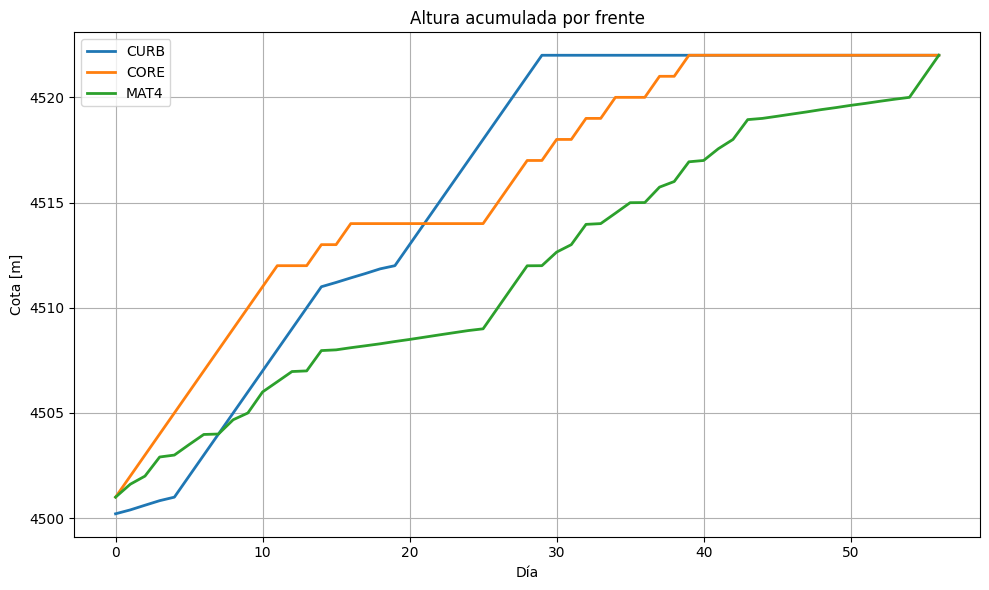

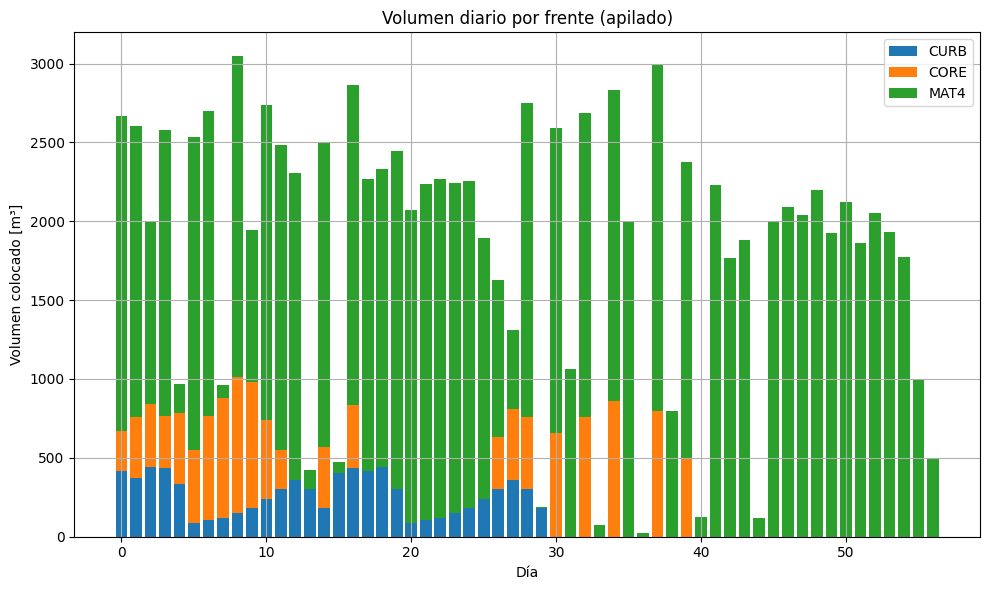

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar los resultados
heights = pd.read_csv('daily_heights.csv')    # columnas: Dia, H_CURB, H_CORE, H_MAT4
volumes = pd.read_csv('daily_volumes.csv')    # columnas: Dia, V_CURB, V_CORE, V_MAT4

# 2. Gráfica de alturas acumuladas
plt.figure(figsize=(10, 6))
plt.plot(heights['Dia'], heights['H_CURB'], label='CURB',    linewidth=2)
plt.plot(heights['Dia'], heights['H_CORE'], label='CORE',    linewidth=2)
plt.plot(heights['Dia'], heights['H_MAT4'], label='MAT4',    linewidth=2)
plt.xlabel('Día')
plt.ylabel('Cota [m]')
plt.title('Altura acumulada por frente')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Gráfica de volumen colocado por día (barras apiladas)
plt.figure(figsize=(10, 6))
plt.bar(volumes['Dia'], volumes['V_CURB'], label='CURB')
plt.bar(volumes['Dia'], volumes['V_CORE'], bottom=volumes['V_CURB'], label='CORE')
bottom_stack = volumes['V_CURB'] + volumes['V_CORE']
plt.bar(volumes['Dia'], volumes['V_MAT4'], bottom=bottom_stack, label='MAT4')
plt.xlabel('Día')
plt.ylabel('Volumen colocado [m³]')
plt.title('Volumen diario por frente (apilado)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


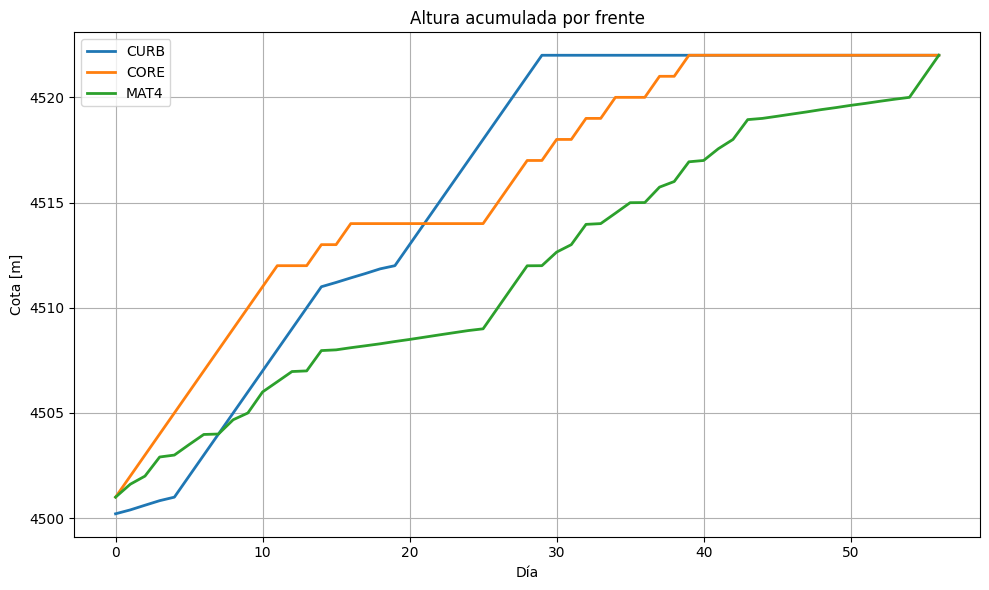

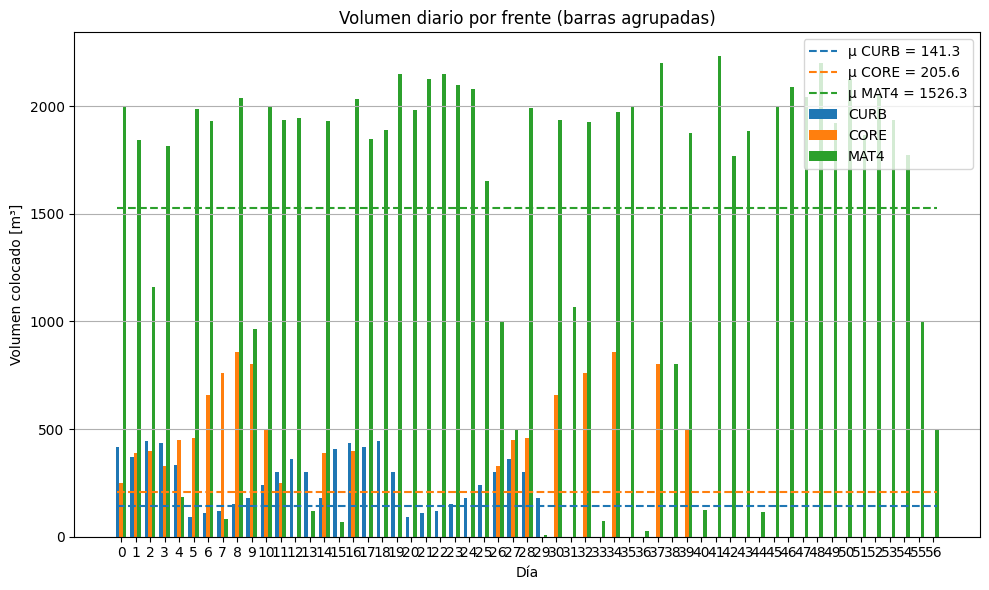

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar datos
heights = pd.read_csv('daily_heights.csv')    # Dia, H_CURB, H_CORE, H_MAT4
volumes = pd.read_csv('daily_volumes.csv')    # Dia, V_CURB, V_CORE, V_MAT4

# 2. Gráfica de alturas acumuladas (líneas)
plt.figure(figsize=(10, 6))
plt.plot(heights['Dia'], heights['H_CURB'], label='CURB',   linewidth=2)
plt.plot(heights['Dia'], heights['H_CORE'], label='CORE',   linewidth=2)
plt.plot(heights['Dia'], heights['H_MAT4'], label='MAT4',   linewidth=2)
plt.xlabel('Día')
plt.ylabel('Cota [m]')
plt.title('Altura acumulada por frente')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Gráfica de volumen diario por frente (barras agrupadas + medias)
dias = volumes['Dia'].values
bar_width = 0.25
x = np.arange(len(dias))

# Valores
v_curb = volumes['V_CURB'].values
v_core = volumes['V_CORE'].values
v_mat4 = volumes['V_MAT4'].values

# Crear barras agrupadas
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width, v_curb,  width=bar_width, label='CURB')
plt.bar(x,               v_core, width=bar_width, label='CORE')
plt.bar(x + bar_width,   v_mat4, width=bar_width, label='MAT4')

# Líneas punteadas de media
mean_curb = v_curb.mean()
mean_core = v_core.mean()
mean_mat4 = v_mat4.mean()
plt.hlines(mean_curb, x.min() - bar_width, x.max() + bar_width,
           colors='C0', linestyles='--', label=f'μ CURB = {mean_curb:.1f}')
plt.hlines(mean_core, x.min() - bar_width, x.max() + bar_width,
           colors='C1', linestyles='--', label=f'μ CORE = {mean_core:.1f}')
plt.hlines(mean_mat4, x.min() - bar_width, x.max() + bar_width,
           colors='C2', linestyles='--', label=f'μ MAT4 = {mean_mat4:.1f}')

# Ajustes finales
plt.xticks(x, dias)
plt.xlabel('Día')
plt.ylabel('Volumen colocado [m³]')
plt.title('Volumen diario por frente (barras agrupadas)')
plt.legend(loc='upper right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


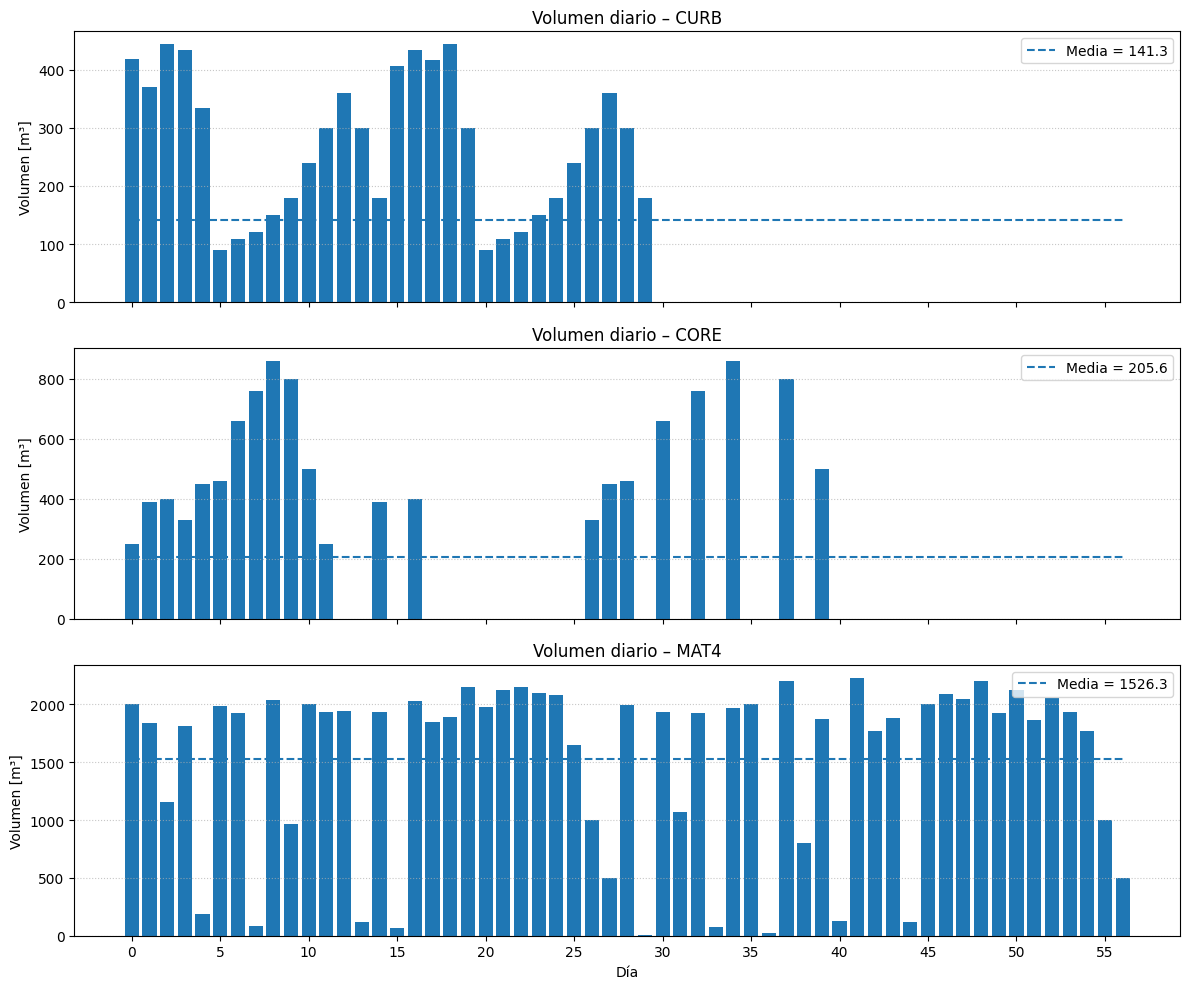

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos
vol = pd.read_csv('daily_volumes.csv')  # Dia, V_CURB, V_CORE, V_MAT4

# Configuración de ejes
dias = vol['Dia']
max_dia = dias.max()
xticks = np.arange(0, max_dia+1, 5)

# Diccionario para iterar
series = {
    'CURB': 'V_CURB',
    'CORE': 'V_CORE',
    'MAT4': 'V_MAT4'
}

# Crear subplots: 3 filas x 1 columna
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for ax, (name, col) in zip(axes, series.items()):
    y = vol[col]
    ax.bar(dias, y, width=0.8)
    # Línea media
    mean = y.mean()
    ax.hlines(mean, 0, max_dia, linestyles='--', label=f'Media = {mean:.1f}')
    # Etiquetas y estilo
    ax.set_ylabel('Volumen [m³]')
    ax.set_title(f'Volumen diario – {name}')
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle=':', alpha=0.7)

# Ajustes del eje x
axes[-1].set_xlabel('Día')
axes[-1].set_xticks(xticks)
plt.tight_layout()
plt.show()


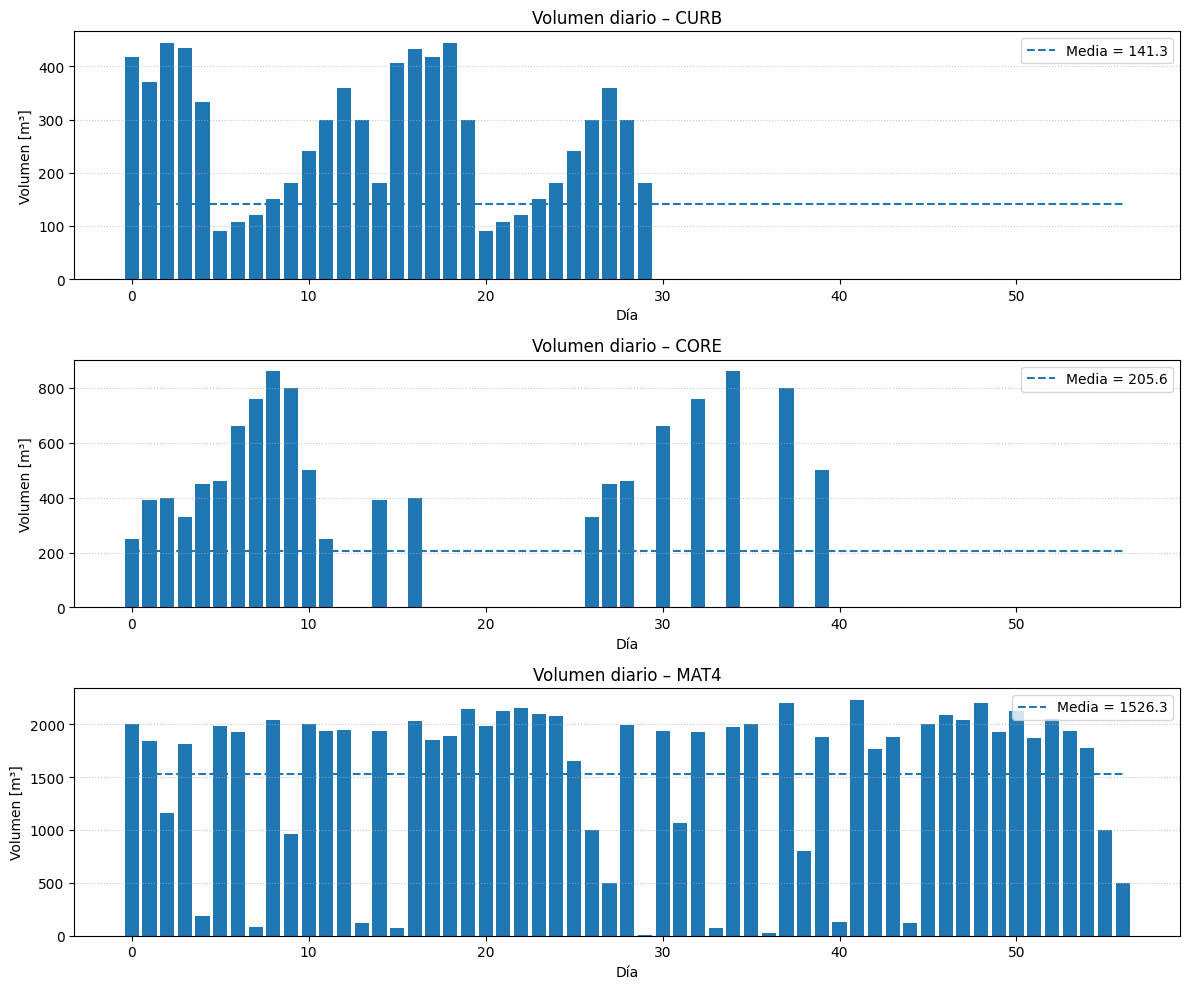

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos
vol = pd.read_csv('daily_volumes.csv')  # columnas: Dia, V_CURB, V_CORE, V_MAT4

# Configuración de ejes
max_dia = vol['Dia'].max()
xticks = np.arange(0, max_dia+1, 10)

# Mapeo de series
series = {
    'CURB': 'V_CURB',
    'CORE': 'V_CORE',
    'MAT4': 'V_MAT4'
}

# Crear subplots: 3 filas x 1 columna, sin sharex para mostrar etiquetas en cada uno
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

for ax, (name, col) in zip(axes, series.items()):
    y = vol[col]
    ax.bar(vol['Dia'], y, width=0.8)
    # Línea de media
    mean = y.mean()
    ax.hlines(mean, 0, max_dia, linestyles='--', label=f'Media = {mean:.1f}')
    # Etiquetas y estilo
    ax.set_ylabel('Volumen [m³]')
    ax.set_title(f'Volumen diario – {name}')
    ax.set_xticks(xticks)
    ax.set_xlabel('Día')
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()
